In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

# %cd /content/drive/MyDrive/Studia-II/Uczenie-Maszynowe/Lista1/Zad2

0. Znajdź i pobierz zbiór danych BANK MARKETING z repozytorium danych UCI. Dowiedz
się co opisują pobrane dane.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
bank = pd.read_csv("bank.csv", sep=";")

   The classification goal is to predict if the client will subscribe a term deposit (variable y).

5. Number of Instances: 45211 for bank-full.csv (4521 for bank.csv)

6. Number of Attributes: 16 + output attribute.

7. Attribute information:

   For more information, read [Moro et al., 2011].

   Input variables:
   # bank client data:
   1 - age (numeric)
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services") 
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)
   4 - education (categorical: "unknown","secondary","primary","tertiary")
   5 - default: has credit in default? (binary: "yes","no")
   6 - balance: average yearly balance, in euros (numeric) 
   7 - housing: has housing loan? (binary: "yes","no")
   8 - loan: has personal loan? (binary: "yes","no")
   # related with the last contact of the current campaign:
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular") 
  10 - day: last contact day of the month (numeric)
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
  12 - duration: last contact duration, in seconds (numeric)
   # other attributes:
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)
  15 - previous: number of contacts performed before this campaign and for this client (numeric)
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  Output variable (desired target):
  17 - y - has the client subscribed a term deposit? (binary: "yes","no")

1. Zrób histogram atrybutu duration dla całości danych. Następnie zrób analogiczne dwa histo-
gramy, osobno dla próbek pozytywnych i negatywnych (atrybut y równy yes albo no, odpo-
wiednio). Co ciekawego widać na tych wykresach?

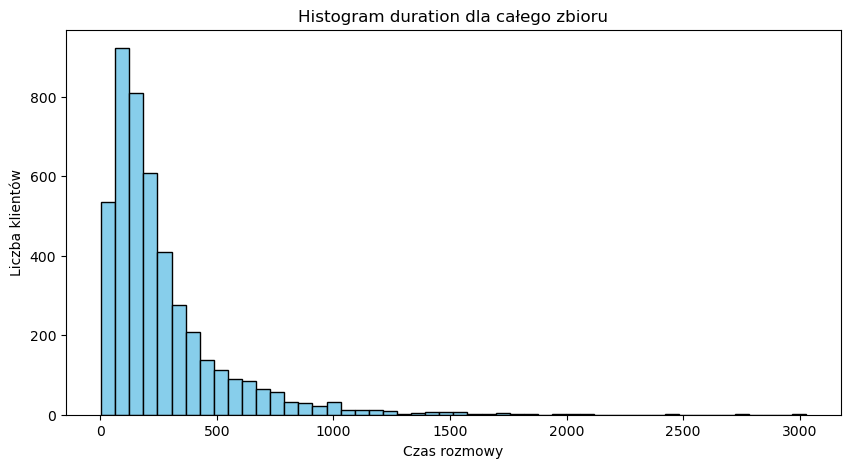

In [4]:
plt.figure(figsize=(10, 5))
plt.hist(bank["duration"], bins=50, color="skyblue", edgecolor="black") # histogram z 50 binami rozłożonymi równomiernie na osi x
plt.title("Histogram duration dla całego zbioru")
plt.xlabel("Czas rozmowy")
plt.ylabel("Liczba klientów")
plt.show()

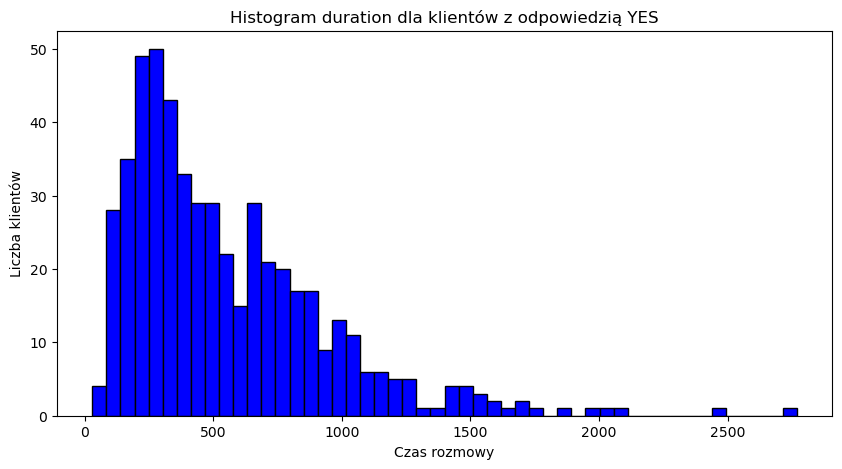

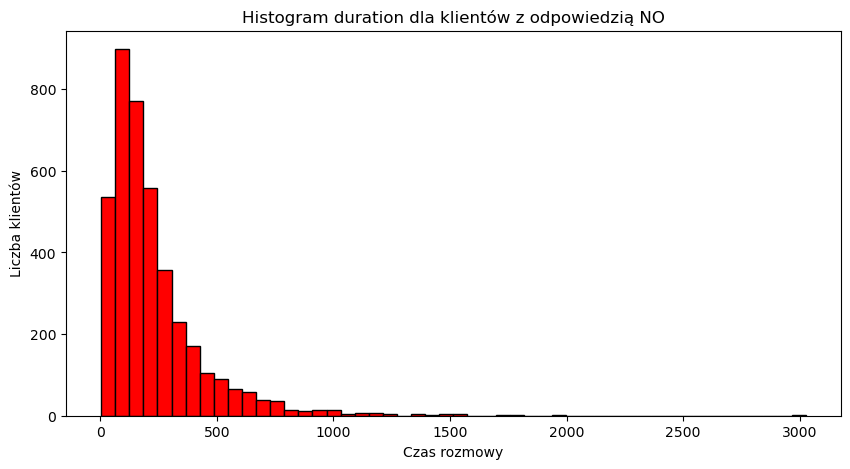

In [5]:
# Histogram dla klientów z odpowiedzią 'yes'
plt.figure(figsize=(10, 5))
plt.hist(bank[bank["y"]=="yes"]["duration"], bins=50, color="blue", edgecolor="black")
plt.title("Histogram duration dla klientów z odpowiedzią YES")
plt.xlabel("Czas rozmowy")
plt.ylabel("Liczba klientów")
plt.show()

# Histogram dla klientów z odpowiedzią 'no'
plt.figure(figsize=(10, 5))
plt.hist(bank[bank["y"]=="no"]["duration"], bins=50, color="red", edgecolor="black")
plt.title("Histogram duration dla klientów z odpowiedzią NO")
plt.xlabel("Czas rozmowy")
plt.ylabel("Liczba klientów")
plt.show()


Średnia osoba, która odpowiadziała 'yes' rozmawiała dłużej niż ta co odpowiedziała 'no'.
Im dłuższa rozmowa tym większa szansa na pozytywną odpowiedź.

2. Zrób histogram atrybutu balance dla osób powyżej 25 roku życia (atrybut age większy niż 25).
Zapoznaj się z pakietem ipywidgets, a następnie przekształć swój wykres w interaktywny z
suwakiem do wybierania granicy wieku i zobacz jak zmienia się histogram.

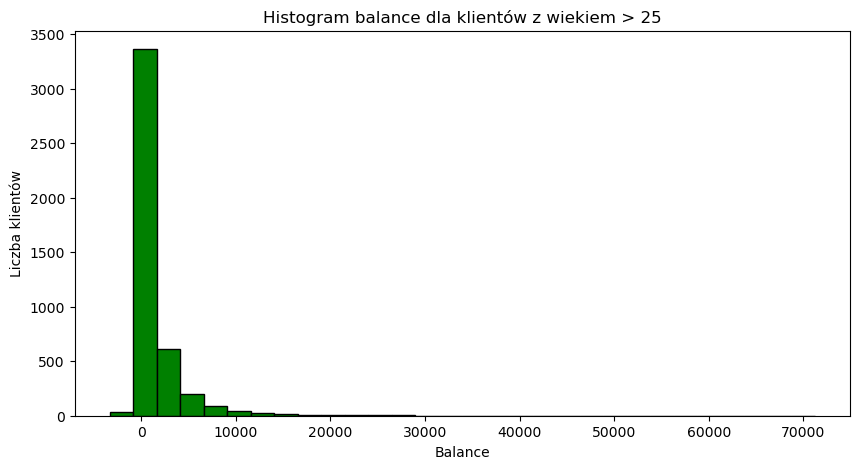

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(bank[bank["age"]>25]["balance"], bins=30, color="green", edgecolor="black")
plt.title("Histogram balance dla klientów z wiekiem > 25")
plt.xlabel("Balance")
plt.ylabel("Liczba klientów")
plt.show()

In [7]:
import ipywidgets as widgets
from ipywidgets import interact

# Funkcja rysująca histogram dla wybranego progu wieku, nic specjalnego, po prostu tak jakby się to normalnie robiło
def plot_balance(min_age=25):
    plt.figure(figsize=(10, 5))
    plt.hist(bank[bank["age"]>=min_age]["balance"], bins=30, color="green", edgecolor="black")
    plt.title(f"Histogram balance dla klientów z wiekiem >= {min_age}")
    plt.xlabel("Balance")
    plt.ylabel("Liczba klientów")
    plt.show()

# Suwaki do interaktywnego wyboru progu wieku, funkcja, a do jej parametru przekazujemy widget)
interact(plot_balance, min_age=widgets.IntSlider(min=bank["age"].min(), max=bank["age"].max(), step=1, value=25)) # step to wartość skoku, value to wartość początkowa

interactive(children=(IntSlider(value=25, description='min_age', max=87, min=19), Output()), _dom_classes=('wi…

<function __main__.plot_balance(min_age=25)>

3. Dla ustalonego progu, t = 360, czasu trwania rozmowy (atrybut duration), wyznacz próbki
danych z atrybutem duration powyżej progu t. Policz ile procent z nich to próbki pozytywne.
Powtórz obliczenia dla różnych t i zrób wykres: na osi X próg t, na osi Y procent próbek
pozytywnych. Spróbuj wytłumaczyć zjawisko widoczne na wykresie.

In [8]:
t = 360

subset = bank[bank["duration"] > t] # to te próbki
positive = (subset["y"] == "yes").sum()
percent = 100 * positive / len(subset) if len(subset) > 0 else None

print(f"Dla progu t={t} sekund, odsetek klientów, którzy odpowiedzieli 'yes': {percent:.2f}% (liczba klientów: {len(subset)})")

Dla progu t=360 sekund, odsetek klientów, którzy odpowiedzieli 'yes': 31.63% (liczba klientów: 980)


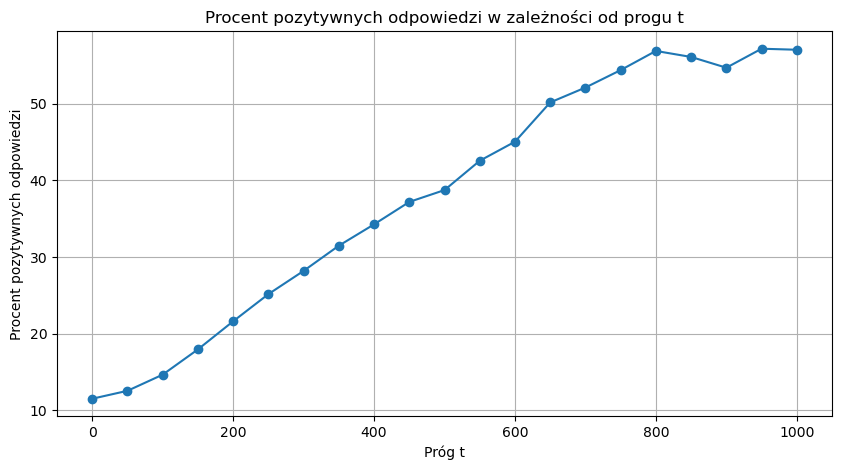

In [9]:
thresholds = np.arange(0, 1001, 50) # [0, 50, 100, ..., 1000]
results = []

for t in thresholds:
    subset = bank[bank["duration"] > t]
    positive = (subset["y"] == "yes").sum()
    percent = 100 * positive / len(subset) if len(subset) > 0 else None # jak None to nie rysujemy punktu
    results.append(percent)

plt.figure(figsize=(10,5))
plt.plot(thresholds, results, marker="o")
plt.title("Procent pozytywnych odpowiedzi w zależności od progu t")
plt.xlabel("Próg t")
plt.ylabel("Procent pozytywnych odpowiedzi")
plt.grid(True)
plt.show()

4. Powtórz poprzedni punkt dla atrybutu balance. Wyobraź sobie, że przeprowadzasz kampanię
marketingową lokat bankowych. Możesz kontaktować się z losowo wybranymi (z rozkładem
jednostajnym na całych danych) klientami banku, albo jedynie z klientami o saldzie (atrybut
balance) powyżej ustalonego progu (możesz sam ustalić ten próg). Która strategia jest lepsza?
Jaki próg wybrać?

In [10]:
# Strategia 1 - wybieramy jednostanie spośród wszysktich klientów
percent_yes = 100 * (bank["y"] == "yes").sum() / len(bank)
print(f"Strategia 1 - odsetek pozytywnych odpowiedzi: {percent_yes:.2f}%")

Strategia 1 - odsetek pozytywnych odpowiedzi: 11.52%


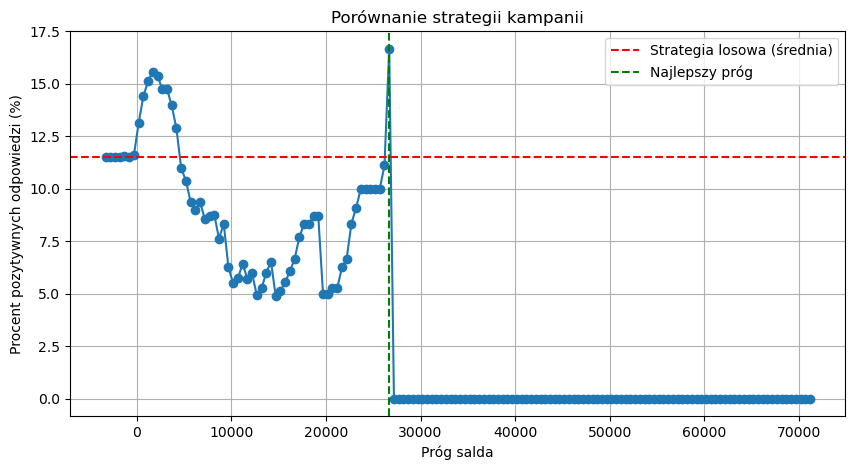

Strategia 2 - najlepszy próg salda: 26687, odsetek pozytywnych odpowiedzi: 16.67%


In [11]:
thresholds = np.arange(bank["balance"].min(), bank["balance"].max(), 500)
results = []

best_threshold, best_percent = -np.inf, -np.inf

for t in thresholds:
    subset = bank[bank["balance"] > t]
    positive = (subset["y"] == "yes").sum()
    percent = 100 * positive / len(subset) if len(subset) > 0 else None # jak None to nie rysujemy punktu
    results.append(percent)
    best_threshold, best_percent = (t, percent) if percent is not None and percent > best_percent else (best_threshold, best_percent)


plt.figure(figsize=(10,5))
plt.plot(thresholds, results, marker="o")
plt.axhline(y=percent_yes, linestyle="--", color="red", label="Strategia losowa (średnia)")
plt.axvline(x=best_threshold, color="green", linestyle="--", label="Najlepszy próg")
plt.title("Porównanie strategii kampanii")
plt.xlabel("Próg salda")
plt.ylabel("Procent pozytywnych odpowiedzi (%)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Strategia 2 - najlepszy próg salda: {best_threshold}, odsetek pozytywnych odpowiedzi: {best_percent:.2f}%")


Zalezy to co znaczy, że strategia jest dobra. Jeśli mamy na myśli jedynie to, że statystycznie będzie miała najlepsza skuteczność (tzn procent odpowiedzi 'yes') to tamten wynik jest najlepszy. Jednak jesli w grę wchodzi co innego, jakieś inne metryki to trzeba się inaczej zastanowić. 

5. Podziel losowo zbiór danych na dwie części porównywalnej wielkości. Używając pierwszej części
danych, zrób wykres opisany w pkt. 4 i ustal próg (według własnego pomysłu). Przyjmij,
że klienci z saldem powyżej ustalonego progu powinni być zainteresowani lokatą bankową
(powinni być próbkami pozytywnymi). Oblicz ilu z nich, procentowo, nie było. Oblicz też
ilu zainteresowanych lokatą klientów miało saldo nie większe od ustalonego progu. Następnie
policz takie błędy modelu na drugiej części danych. Powtórz obliczenia dla różnych wartości
progów. Zrób wykres (według własnego pomysłu) prezentujący wyniki. Ostatecznie, to jaki
próg wybrać?

In [12]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(bank, test_size=0.2, random_state=42)

In [13]:
def calculate_price(tp, tn, fp, fn, cost_all, price_positive):
    return (tp + fp) * (-cost_all) + tp * price_positive

In [14]:
def calculate_metrics(data, threshold):
    subset = data[data["balance"] > threshold]
    tp = ((subset["y"] == "yes")).sum()  
    fp = ((subset["y"] == "no")).sum()  
    fn = ((data["y"] == "yes")).sum() - tp  
    tn = ((data["y"] == "no")).sum() - fp  
    return tp, tn, fp, fn

In [15]:
def evaluate_threshold(data, threshold, cost_all, price_positive):
    subset = data[data['balance'] > threshold]
    positive = (subset["y"] == "yes").sum()
    total = len(subset)
    tp, tn, fp, fn = calculate_metrics(data, threshold)

    price = calculate_price(tp, tn, fp, fn, cost_all, price_positive)

    return total, positive, price

In [16]:
def find_best_threshold(data, cost_all, price_positive):
    thresholds = range(data["balance"].min(), data["balance"].max())
    best_threshold, best_price = -np.inf, -np.inf
    for t in thresholds:
        total, positive, price = evaluate_threshold(data, t, cost_all, price_positive)
        if price > best_price:
            best_threshold, best_price = t, price, 
    return best_threshold, best_price

In [17]:
def plot_data(data, threshold):
    metrics = calculate_metrics(data, threshold)
    print(f"Próg: {threshold}, Metryki: {metrics}")
    plt.figure(figsize=(10, 5))
    plt.hist(data[data["y"]=="yes"]["balance"], bins=30, alpha=0.5, label="Yes", color="blue", edgecolor="black")
    plt.hist(data[data["y"]=="no"]["balance"], bins=30, alpha=0.5, label="No", color="red", edgecolor="black")
    plt.axvline(x=threshold, color="green", linestyle="--", label="Wybrany próg")
    plt.title("Histogram balance z podziałem na odpowiedzi")
    plt.xlabel("Balance")
    plt.ylabel("Liczba klientów")
    plt.legend()
    plt.show()

In [18]:
best_threshold, best_price = find_best_threshold(train, cost_all=1, price_positive=7)

Próg: 1890, Metryki: (np.int64(119), np.int64(2566), np.int64(627), np.int64(304))


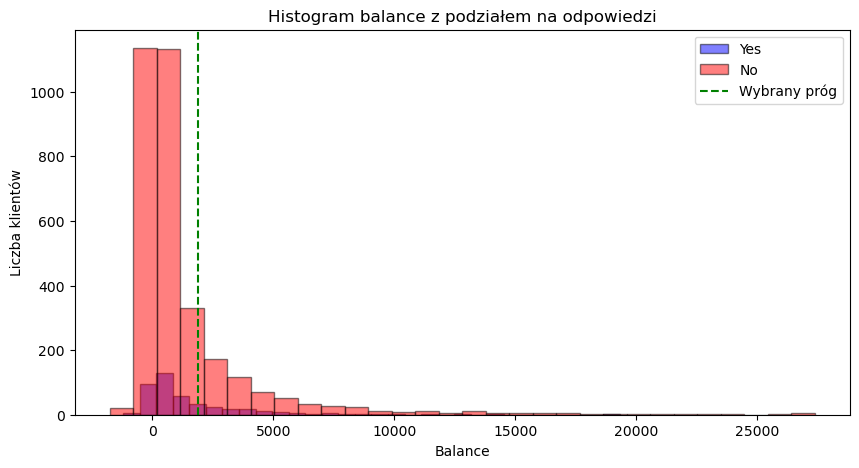

In [19]:
plot_data(train, best_threshold)

Próg: 1890, Metryki: (np.int64(30), np.int64(649), np.int64(158), np.int64(68))


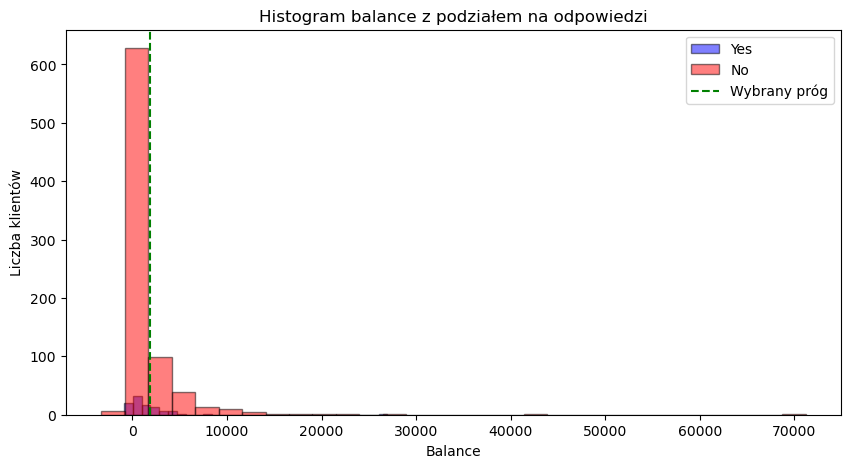

In [20]:
plot_data(test, best_threshold)